<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Many_Mode_Filling_Shell_Capacity_V10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet Many-Mode Filling / Shell Capacity V10

**Purpose.** V10 extends the V6b--V9 electron-like packet sequence from two-packet antisymmetry into a finite many-mode occupancy test.

Prior sequence:
- V6b: spectral positive-branch Dirac-like propagation
- V7: response-potential dynamics
- V8c: gauge-covariant phase coupling
- V9: fermion-like antisymmetry and exclusion bridge

V10 asks whether a finite set of ECSM electron-like packet modes supports:
1. duplicate-occupancy collapse,
2. orthogonal-mode filling,
3. determinant / Gram-volume exclusion,
4. finite capacity,
5. shell-like closure patterns,
6. chi-deformed preservation of the filling structure.

This notebook is intentionally a **minimal bridge test**, not a full many-body QFT or full atomic shell derivation.

In [1]:
# ============================================================
# CELL 1 — SETUP
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os, math
from pathlib import Path

VERSION = "V10"
OUT = Path("ecsm_electron_like_many_mode_filling_shell_capacity_v10_out")
OUT.mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=6, suppress=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(OUT / name, dpi=180, bbox_inches="tight")
    plt.show()

print("Output directory:", OUT)

Output directory: ecsm_electron_like_many_mode_filling_shell_capacity_v10_out


In [2]:
# ============================================================
# CELL 2 — GRID, DIRAC-LIKE ALGEBRA, AND BASIC HELPERS
# ============================================================

N = 512
L = 160.0
dx = L / N
x = (np.arange(N) - N//2) * dx
k = 2*np.pi*np.fft.fftfreq(N, d=dx)

# Dirac representation, 1D propagation uses alpha_1.
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)
Z2 = np.zeros((2,2), dtype=complex)

alpha1 = np.block([[Z2, sigma_x], [sigma_x, Z2]])
alpha2 = np.block([[Z2, sigma_y], [sigma_y, Z2]])
alpha3 = np.block([[Z2, sigma_z], [sigma_z, Z2]])
beta   = np.block([[I2, Z2], [Z2, -I2]])
I4 = np.eye(4, dtype=complex)

m_lock = 0.225463435330576

def Hk(kval, chi=1.0):
    # Same response deformation form as the V6b/V9 bridge:
    # chi affects effective transport speed through sqrt(chi).
    return np.sqrt(chi) * kval * alpha1 + m_lock * beta

def eigensystem(kval, chi=1.0):
    vals, vecs = np.linalg.eigh(Hk(kval, chi=chi))
    return vals, vecs

def norm_psi(psi):
    return float(np.sum(np.abs(psi)**2) * dx)

def density(psi):
    return np.sum(np.abs(psi)**2, axis=1).real

def inner_single(a,b):
    return np.sum(np.conj(a)*b) * dx

def expectation_x(psi):
    rho = density(psi)
    return float(np.sum(x*rho)*dx / (np.sum(rho)*dx))

def width_x(psi):
    rho = density(psi)
    nrm = np.sum(rho)*dx
    xm = np.sum(x*rho)*dx/nrm
    return float(np.sqrt(np.sum((x-xm)**2*rho)*dx/nrm))

def evolve_exact(psi, t, chi=1.0):
    psik = np.fft.fft(psi, axis=0)
    outk = np.zeros_like(psik)
    for i, kval in enumerate(k):
        vals, vecs = eigensystem(kval, chi=chi)
        coeff = vecs.conj().T @ psik[i]
        outk[i] = vecs @ (np.exp(-1j*vals*t) * coeff)
    return np.fft.ifft(outk, axis=0)

def project_branch_weights(psi, chi=1.0):
    psik = np.fft.fft(psi, axis=0)
    wp = 0.0
    wn = 0.0
    for i, kval in enumerate(k):
        vals, vecs = eigensystem(kval, chi=chi)
        coeff = vecs.conj().T @ psik[i]
        # FFT normalization consistent with prior notebooks.
        weights = (dx/N) * np.abs(coeff)**2
        wp += np.sum(weights[vals > 0])
        wn += np.sum(weights[vals < 0])
    return float(np.real(wp)), float(np.real(wn))

# Algebra closure tests.
alpha_list = [alpha1, alpha2, alpha3]
alpha_rows = []
for idx, A in enumerate(alpha_list, start=1):
    alpha_rows.append({"test": f"alpha_{idx}^2=I", "error": float(np.max(np.abs(A@A - I4)))})
    alpha_rows.append({"test": f"{{alpha_{idx},beta}}=0", "error": float(np.max(np.abs(A@beta + beta@A)))})
for i in range(3):
    for j in range(i+1,3):
        alpha_rows.append({"test": f"{{alpha_{i+1},alpha_{j+1}}}=0", "error": float(np.max(np.abs(alpha_list[i]@alpha_list[j] + alpha_list[j]@alpha_list[i])))})

alpha_rows.append({"test": "beta^2=I", "error": float(np.max(np.abs(beta@beta - I4)))})
alpha_df = pd.DataFrame(alpha_rows)
alpha_df.to_csv(OUT/"alpha_beta_algebra_tests_v10.csv", index=False)
print("Max alpha/beta error:", alpha_df["error"].max())
display(alpha_df)

print("Grid:", {"N": N, "L": L, "dx": dx, "k_min": float(k.min()), "k_max": float(k.max())})

Max alpha/beta error: 0.0


,test,error
0,alpha_1^2=I,0.0
1,"{alpha_1,beta}=0",0.0
2,alpha_2^2=I,0.0
3,"{alpha_2,beta}=0",0.0
4,alpha_3^2=I,0.0
5,"{alpha_3,beta}=0",0.0
6,"{alpha_1,alpha_2}=0",0.0
7,"{alpha_1,alpha_3}=0",0.0
8,"{alpha_2,alpha_3}=0",0.0
9,beta^2=I,0.0


Grid: {'N': 512, 'L': 160.0, 'dx': 0.3125, 'k_min': -10.053096491487338, 'k_max': 10.013826583317465}


{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V9 fixed V3b/V4b/V5/V6b/V7/V8c electron-like packet"
}
Reference norm: 0.9999999999999997
Reference x_mean: 36.930784340724045
Reference width: 26.710941748873115
Reference branch weights: (1.0000000000000002, 4.790756110929919e-32)


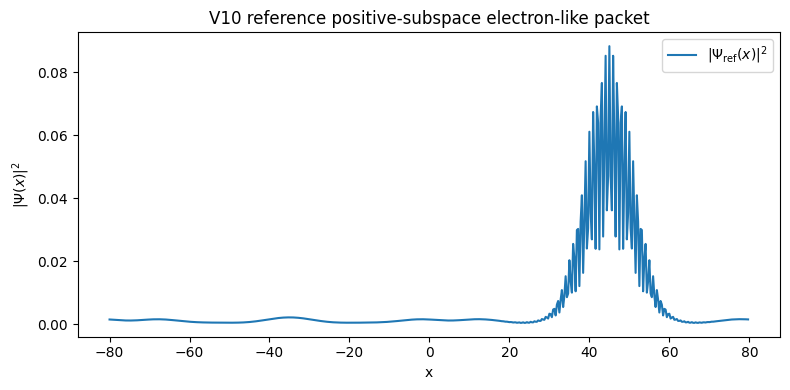

In [3]:
# ============================================================
# CELL 3 — ELECTRON-LIKE PACKET SUMMARY AND POSITIVE-BRANCH BUILDER
# ============================================================

packet = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V9 fixed V3b/V4b/V5/V6b/V7/V8c electron-like packet"
}
pd.DataFrame([packet]).to_csv(OUT/"fixed_packet_summary_v10.csv", index=False)
print(json.dumps(packet, indent=2))

def positive_spinor_for_k(kval, spin_index=0, chi=1.0):
    vals, vecs = eigensystem(kval, chi=chi)
    pos_inds = np.where(vals > 0)[0]
    # There are two positive-energy spin states. spin_index selects one.
    return vecs[:, pos_inds[spin_index % len(pos_inds)]]

def build_positive_packet(x0=-35.0, k0=1.0, sigma=8.0, spin_index=0, chi=1.0):
    # Build in k-space, using a Gaussian momentum profile with phase centre x0.
    dk = np.angle(np.exp(1j*(k-k0)))  # periodic wrapped offset around k0
    A_k = np.exp(-0.5*(dk*sigma)**2) * np.exp(-1j*k*x0)
    psik = np.zeros((N,4), dtype=complex)
    for i, kval in enumerate(k):
        psik[i,:] = A_k[i] * positive_spinor_for_k(kval, spin_index=spin_index, chi=chi)
    psi = np.fft.ifft(psik, axis=0)
    psi = psi / np.sqrt(norm_psi(psi))
    return psi

# Reference single packet.
psi_ref = build_positive_packet(x0=-35.0, k0=1.0, sigma=8.0, spin_index=0, chi=1.0)
rho_ref = density(psi_ref)
wp_ref, wn_ref = project_branch_weights(psi_ref)

pd.DataFrame({"x":x, "rho_ref":rho_ref}).to_csv(OUT/"reference_packet_density_v10.csv", index=False)

print("Reference norm:", norm_psi(psi_ref))
print("Reference x_mean:", expectation_x(psi_ref))
print("Reference width:", width_x(psi_ref))
print("Reference branch weights:", (wp_ref, wn_ref))

plt.figure(figsize=(8,4))
plt.plot(x, rho_ref, label=r"$|\Psi_{\rm ref}(x)|^2$")
plt.xlabel("x")
plt.ylabel(r"$|\Psi(x)|^2$")
plt.title("V10 reference positive-subspace electron-like packet")
plt.legend()
savefig("fig_v10_reference_packet_density.png")

Number of basis modes: 8
Max diagonal error: 4.440907666963733e-16
Max off-diagonal overlap: 0.010134227381488376


,mode_id,shell_id,x0,spin_index,x_mean,width,positive_branch_weight,negative_branch_weight
0,0,1,-45.0,0,28.799425,24.291496,1.0,4.785564e-32
1,1,1,-45.0,1,19.403983,35.024793,1.0,5.717867e-32
2,2,2,-15.0,0,53.236060,32.015469,1.0,4.949288e-32
3,3,2,-15.0,1,40.418869,41.844793,1.0,5.775824e-32
4,4,3,15.0,0,-53.330235,31.858349,1.0,4.882930e-32
5,5,3,15.0,1,-40.527928,41.739175,1.0,5.622702e-32
6,6,4,45.0,0,-28.884725,24.190004,1.0,5.957008e-32
7,7,4,45.0,1,-19.529582,34.954916,1.0,5.322673e-32


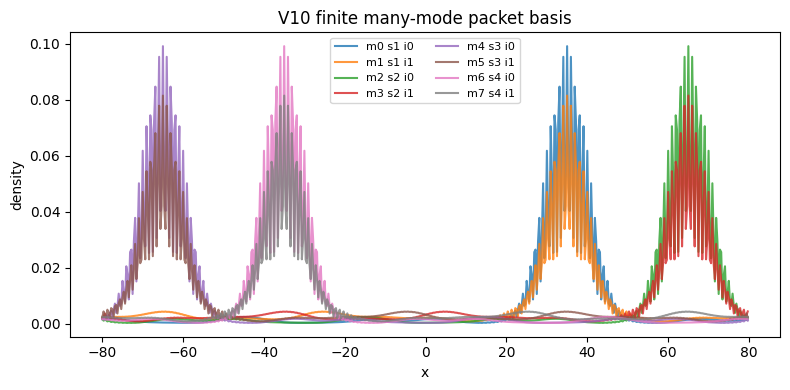

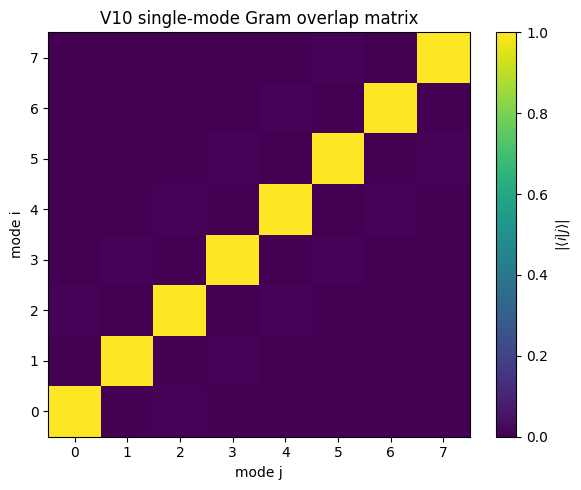

In [4]:
# ============================================================
# CELL 4 — FINITE MANY-MODE BASIS CONSTRUCTION
# ============================================================

# Build a finite packet-mode basis. We use multiple spatial centres and two internal
# positive-energy spin labels. This provides a simple finite capacity test.
centres = [-45.0, -15.0, 15.0, 45.0]
spin_indices = [0, 1]

basis = []
for shell_id, x0 in enumerate(centres, start=1):
    for spin_idx in spin_indices:
        psi = build_positive_packet(x0=x0, k0=1.0, sigma=7.0, spin_index=spin_idx, chi=1.0)
        basis.append({
            "mode_id": len(basis),
            "shell_id": shell_id,
            "x0": x0,
            "spin_index": spin_idx,
            "psi": psi,
            "x_mean": expectation_x(psi),
            "width": width_x(psi),
            "positive_branch_weight": project_branch_weights(psi)[0],
            "negative_branch_weight": project_branch_weights(psi)[1]
        })

M = len(basis)
print("Number of basis modes:", M)

# Gram matrix of single-particle modes.
G = np.zeros((M,M), dtype=complex)
for i in range(M):
    for j in range(M):
        G[i,j] = inner_single(basis[i]["psi"], basis[j]["psi"])

basis_rows = []
for b in basis:
    row = {k:v for k,v in b.items() if k != "psi"}
    basis_rows.append(row)

basis_df = pd.DataFrame(basis_rows)
basis_df.to_csv(OUT/"many_mode_basis_summary_v10.csv", index=False)

gram_df = pd.DataFrame(np.abs(G), columns=[f"mode_{i}" for i in range(M)])
gram_df.insert(0, "mode_id", np.arange(M))
gram_df.to_csv(OUT/"many_mode_gram_abs_v10.csv", index=False)

print("Max diagonal error:", np.max(np.abs(np.diag(G)-1)))
print("Max off-diagonal overlap:", np.max(np.abs(G - np.eye(M))))

display(basis_df)

plt.figure(figsize=(8,4))
for b in basis:
    plt.plot(x, density(b["psi"]), label=f"m{b['mode_id']} s{b['shell_id']} i{b['spin_index']}", alpha=0.8)
plt.xlabel("x")
plt.ylabel("density")
plt.title("V10 finite many-mode packet basis")
plt.legend(ncol=2, fontsize=8)
savefig("fig_v10_many_mode_basis_densities.png")

plt.figure(figsize=(6,5))
plt.imshow(np.abs(G), origin="lower", aspect="auto")
plt.colorbar(label=r"$|\langle i|j\rangle|$")
plt.xlabel("mode j")
plt.ylabel("mode i")
plt.title("V10 single-mode Gram overlap matrix")
savefig("fig_v10_gram_overlap_matrix.png")

In [5]:
# ============================================================
# CELL 5 — GRAM-DETERMINANT MANY-PACKET OCCUPANCY TESTS
# ============================================================

def gram_for_indices(indices, mode_list=None):
    if mode_list is None:
        mode_list = basis
    n = len(indices)
    GG = np.zeros((n,n), dtype=complex)
    for a, ia in enumerate(indices):
        for b, ib in enumerate(indices):
            GG[a,b] = inner_single(mode_list[ia]["psi"], mode_list[ib]["psi"])
    return GG

def slater_norm_sq(indices, mode_list=None):
    # For a Slater-like antisymmetric product of non-orthogonal one-particle states,
    # the squared norm is det(Gram). Duplicate states force det=0.
    GG = gram_for_indices(indices, mode_list=mode_list)
    return float(np.real(np.linalg.det(GG)))

def duplicate_collapse_test(mode_id=0):
    # Explicit duplicate state in a two-particle Slater Gram determinant.
    psi = basis[mode_id]["psi"]
    GG = np.array([[inner_single(psi,psi), inner_single(psi,psi)],
                   [inner_single(psi,psi), inner_single(psi,psi)]], dtype=complex)
    return float(np.real(np.linalg.det(GG)))

tests = []
tests.append({
    "case": "single mode",
    "indices": [0],
    "n_particles": 1,
    "slater_norm_sq": slater_norm_sq([0]),
    "allowed": slater_norm_sq([0]) > 1e-12
})
tests.append({
    "case": "duplicate occupancy [0,0]",
    "indices": [0,0],
    "n_particles": 2,
    "slater_norm_sq": duplicate_collapse_test(0),
    "allowed": duplicate_collapse_test(0) > 1e-12
})
tests.append({
    "case": "same shell orthogonal internal [0,1]",
    "indices": [0,1],
    "n_particles": 2,
    "slater_norm_sq": slater_norm_sq([0,1]),
    "allowed": slater_norm_sq([0,1]) > 1e-8
})
tests.append({
    "case": "two separated same internal [0,2]",
    "indices": [0,2],
    "n_particles": 2,
    "slater_norm_sq": slater_norm_sq([0,2]),
    "allowed": slater_norm_sq([0,2]) > 1e-8
})
tests.append({
    "case": "four modes one per spin in two shells [0,1,2,3]",
    "indices": [0,1,2,3],
    "n_particles": 4,
    "slater_norm_sq": slater_norm_sq([0,1,2,3]),
    "allowed": slater_norm_sq([0,1,2,3]) > 1e-8
})
tests.append({
    "case": "all finite modes",
    "indices": list(range(M)),
    "n_particles": M,
    "slater_norm_sq": slater_norm_sq(list(range(M))),
    "allowed": slater_norm_sq(list(range(M))) > 1e-8
})

occ_df = pd.DataFrame(tests)
occ_df["indices"] = occ_df["indices"].apply(lambda z: ",".join(map(str,z)))
occ_df.to_csv(OUT/"many_packet_occupancy_tests_v10.csv", index=False)
display(occ_df)

print("Duplicate occupancy determinant:", duplicate_collapse_test(0))
print("All-mode filling determinant:", slater_norm_sq(list(range(M))))

,case,indices,n_particles,slater_norm_sq,allowed
0,single mode,0,1,1.000000,True
1,"duplicate occupancy [0,0]","0,0",2,0.000000,False
2,"same shell orthogonal internal [0,1]","0,1",2,1.000000,True
3,"two separated same internal [0,2]","0,2",2,0.999897,True
4,"four modes one per spin in two shells [0,1,2,3]","0,1,2,3",4,0.999795,True
5,all finite modes,"0,1,2,3,4,5,6,7",8,0.999384,True


Duplicate occupancy determinant: 0.0
All-mode filling determinant: 0.9993839006404309


,n_fill,n_combinations,max_slater_norm_sq,median_slater_norm_sq,min_slater_norm_sq,n_allowed_det_gt_1e-8,fraction_allowed
0,1,8,1.000000,1.000000,1.000000,8,1.0
1,2,28,1.000000,1.000000,0.999897,28,1.0
2,3,56,1.000000,0.999897,0.999795,56,1.0
3,4,70,1.000000,0.999897,0.999692,70,1.0
4,5,56,0.999897,0.999795,0.999692,56,1.0
5,6,28,0.999795,0.999692,0.999589,28,1.0
6,7,8,0.999589,0.999538,0.999487,8,1.0
7,8,1,0.999384,0.999384,0.999384,1,1.0


,shell_id,mode_indices,capacity,closure_det,duplicate_collapse_example
0,1,"0,1",2,1.0,0.0
1,2,"2,3",2,1.0,0.0
2,3,"4,5",2,1.0,0.0
3,4,"6,7",2,1.0,0.0


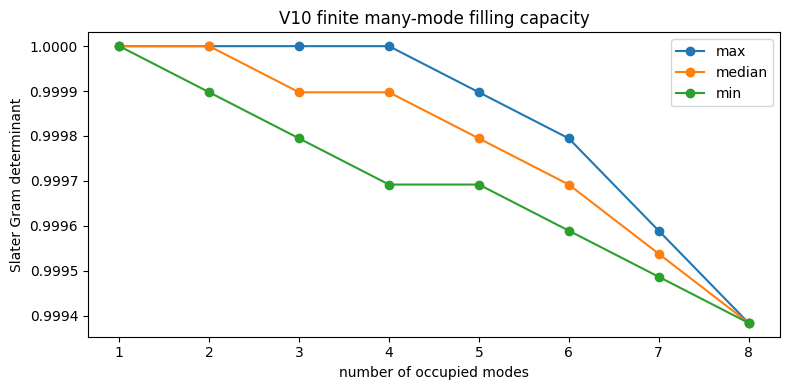

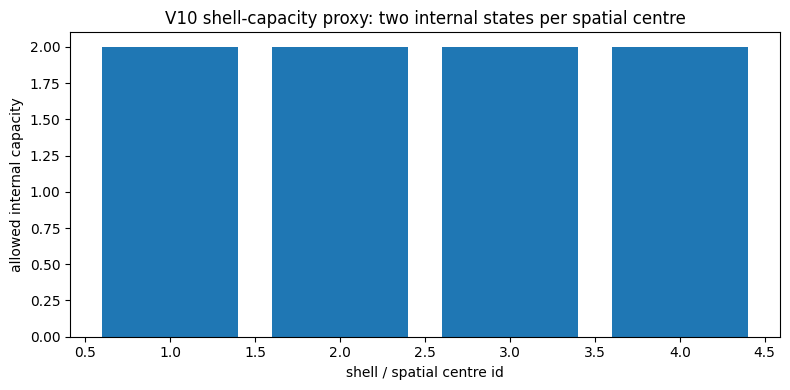

In [6]:
# ============================================================
# CELL 6 — FILLING CAPACITY AND SHELL CLOSURE SCAN
# ============================================================

from itertools import combinations

fill_rows = []
for n_fill in range(1, M+1):
    dets = []
    combos = list(combinations(range(M), n_fill))
    for inds in combos:
        dets.append(slater_norm_sq(list(inds)))
    dets = np.array(dets, dtype=float)
    fill_rows.append({
        "n_fill": n_fill,
        "n_combinations": len(combos),
        "max_slater_norm_sq": float(np.max(dets)),
        "median_slater_norm_sq": float(np.median(dets)),
        "min_slater_norm_sq": float(np.min(dets)),
        "n_allowed_det_gt_1e-8": int(np.sum(dets > 1e-8)),
        "fraction_allowed": float(np.mean(dets > 1e-8))
    })

fill_df = pd.DataFrame(fill_rows)
fill_df.to_csv(OUT/"finite_filling_capacity_scan_v10.csv", index=False)
display(fill_df)

# Shell closure proxy:
# each spatial centre has two positive-subspace internal states.
shell_capacity_rows = []
for shell_id in sorted(set(b["shell_id"] for b in basis)):
    inds = [b["mode_id"] for b in basis if b["shell_id"] == shell_id]
    shell_capacity_rows.append({
        "shell_id": shell_id,
        "mode_indices": ",".join(map(str, inds)),
        "capacity": len(inds),
        "closure_det": slater_norm_sq(inds),
        "duplicate_collapse_example": duplicate_collapse_test(inds[0])
    })

shell_df = pd.DataFrame(shell_capacity_rows)
shell_df.to_csv(OUT/"shell_capacity_summary_v10.csv", index=False)
display(shell_df)

plt.figure(figsize=(8,4))
plt.plot(fill_df["n_fill"], fill_df["max_slater_norm_sq"], marker="o", label="max")
plt.plot(fill_df["n_fill"], fill_df["median_slater_norm_sq"], marker="o", label="median")
plt.plot(fill_df["n_fill"], fill_df["min_slater_norm_sq"], marker="o", label="min")
plt.xlabel("number of occupied modes")
plt.ylabel("Slater Gram determinant")
plt.title("V10 finite many-mode filling capacity")
plt.legend()
savefig("fig_v10_filling_capacity_scan.png")

plt.figure(figsize=(8,4))
plt.bar(shell_df["shell_id"], shell_df["capacity"])
plt.xlabel("shell / spatial centre id")
plt.ylabel("allowed internal capacity")
plt.title("V10 shell-capacity proxy: two internal states per spatial centre")
savefig("fig_v10_shell_capacity_proxy.png")

In [7]:
# ============================================================
# CELL 7 — DUPLICATE INSERTION / CAPACITY OVERFLOW TEST
# ============================================================

# Fill all M modes, then attempt to add a duplicate of mode 0.
# The Gram determinant of M+1 states with a duplicate should collapse to zero.

def slater_norm_sq_for_wavefunctions(waves):
    n = len(waves)
    GG = np.zeros((n,n), dtype=complex)
    for i in range(n):
        for j in range(n):
            GG[i,j] = inner_single(waves[i], waves[j])
    return float(np.real(np.linalg.det(GG)))

all_waves = [b["psi"] for b in basis]
overflow_waves = all_waves + [basis[0]["psi"]]

all_det = slater_norm_sq_for_wavefunctions(all_waves)
overflow_det = slater_norm_sq_for_wavefunctions(overflow_waves)

overflow_df = pd.DataFrame([
    {"case": "all finite modes occupied", "n_states": M, "gram_det": all_det, "allowed": all_det > 1e-8},
    {"case": "all modes plus duplicate mode 0", "n_states": M+1, "gram_det": overflow_det, "allowed": overflow_det > 1e-8},
])
overflow_df.to_csv(OUT/"capacity_overflow_duplicate_test_v10.csv", index=False)
display(overflow_df)

print("All-mode determinant:", all_det)
print("Overflow duplicate determinant:", overflow_det)

,case,n_states,gram_det,allowed
0,all finite modes occupied,8,0.999384,True
1,all modes plus duplicate mode 0,9,0.000000,False


All-mode determinant: 0.9993839006404309
Overflow duplicate determinant: 0.0


,t,all_mode_det,det_error_vs_initial,max_single_norm_error,max_gram_abs_drift,mean_x,x_span
0,0.0,0.999384,5.551115e-16,6.661338e-16,2.220446e-16,-0.051767,106.566294
1,1.0,0.999384,8.881784e-16,6.661338e-16,4.440892e-16,0.174837,106.458361
2,2.0,0.999384,3.330669e-16,4.440892e-16,4.440892e-16,0.395207,106.133754
3,3.0,0.999384,5.551115e-16,6.661338e-16,2.220446e-16,0.603485,105.558498
4,4.0,0.999384,4.440892e-16,4.440892e-16,4.440892e-16,0.790009,104.631196


Max all-mode determinant drift: 8.881784197001252e-16
Max single norm error: 6.661338147750939e-16
Max Gram overlap drift: 4.440892098500626e-16


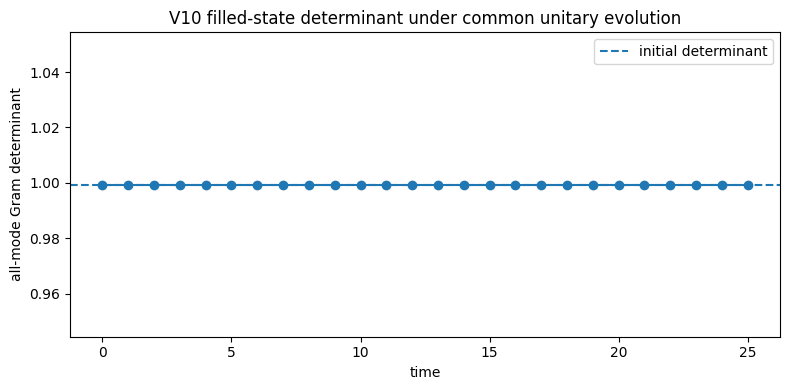

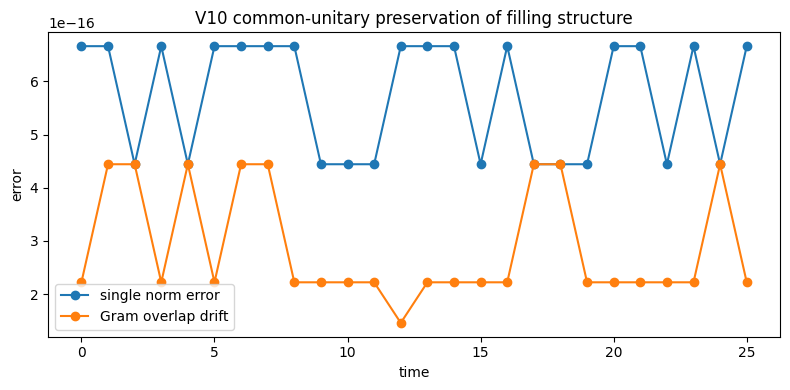

In [8]:
# ============================================================
# CELL 8 — COMMON UNITARY PROPAGATION OF FILLED MANY-MODE STATE
# ============================================================

# Propagate every occupied mode with the same unitary and check that the many-body
# Gram determinant and pairwise overlaps remain stable.

times = np.linspace(0, 25, 26)
prop_rows = []

initial_det = slater_norm_sq(list(range(M)))
initial_G_abs = np.abs(G)

for tt in times:
    evolved = []
    for b in basis:
        evolved.append(evolve_exact(b["psi"], tt, chi=1.0))
    # replace mode_list structure temporarily
    waves = evolved
    det_t = slater_norm_sq_for_wavefunctions(waves)
    GGt = np.zeros((M,M), dtype=complex)
    for i in range(M):
        for j in range(M):
            GGt[i,j] = inner_single(waves[i], waves[j])
    prop_rows.append({
        "t": float(tt),
        "all_mode_det": det_t,
        "det_error_vs_initial": abs(det_t - initial_det),
        "max_single_norm_error": float(max(abs(norm_psi(w)-1.0) for w in waves)),
        "max_gram_abs_drift": float(np.max(np.abs(np.abs(GGt) - initial_G_abs))),
        "mean_x": float(np.mean([expectation_x(w) for w in waves])),
        "x_span": float(max(expectation_x(w) for w in waves) - min(expectation_x(w) for w in waves))
    })

prop_df = pd.DataFrame(prop_rows)
prop_df.to_csv(OUT/"many_mode_unitary_propagation_v10.csv", index=False)
display(prop_df.head())

print("Max all-mode determinant drift:", prop_df["det_error_vs_initial"].max())
print("Max single norm error:", prop_df["max_single_norm_error"].max())
print("Max Gram overlap drift:", prop_df["max_gram_abs_drift"].max())

plt.figure(figsize=(8,4))
plt.plot(prop_df["t"], prop_df["all_mode_det"], marker="o")
plt.axhline(initial_det, linestyle="--", label="initial determinant")
plt.xlabel("time")
plt.ylabel("all-mode Gram determinant")
plt.title("V10 filled-state determinant under common unitary evolution")
plt.legend()
savefig("fig_v10_unitary_filled_determinant.png")

plt.figure(figsize=(8,4))
plt.plot(prop_df["t"], prop_df["max_single_norm_error"], marker="o", label="single norm error")
plt.plot(prop_df["t"], prop_df["max_gram_abs_drift"], marker="o", label="Gram overlap drift")
plt.xlabel("time")
plt.ylabel("error")
plt.title("V10 common-unitary preservation of filling structure")
plt.legend()
savefig("fig_v10_unitary_filling_conservation.png")

Running chi = 1.0
Running chi = 0.95
Running chi = 0.8
Running chi = 0.5
Running chi = 0.2


,chi,sqrt_chi,t_final,all_mode_det,det_error_vs_chi1_initial,max_single_norm_error,max_branch_weight_error,max_negative_branch_weight,x_mean_mean,x_span,max_gram_abs_drift_vs_initial
0,1.00,1.000000,25.0,0.999384,1.110223e-16,6.661338e-16,6.661338e-16,1.365933e-31,-2.475204,58.892874,2.220446e-16
1,0.95,0.974679,25.0,0.999384,1.443290e-15,6.661338e-16,6.661338e-16,2.801952e-06,-2.553600,58.085560,6.661338e-16
2,0.80,0.894427,25.0,0.999384,1.554312e-15,6.661338e-16,8.881784e-16,5.730136e-05,-2.740968,56.294293,4.440892e-16
3,0.50,0.707107,25.0,0.999384,1.221245e-15,6.661338e-16,6.661338e-16,6.823206e-04,-1.467054,56.460188,4.440892e-16
4,0.20,0.447214,25.0,0.999384,1.110223e-16,4.440892e-16,6.661338e-16,5.414024e-03,0.881646,78.627484,2.220446e-16


Max chi single norm error: 6.661338147750939e-16
Max chi branch weight error: 8.881784197001252e-16
Max chi determinant error: 1.5543122344752192e-15
Chi x-span range: 22.333191269922544


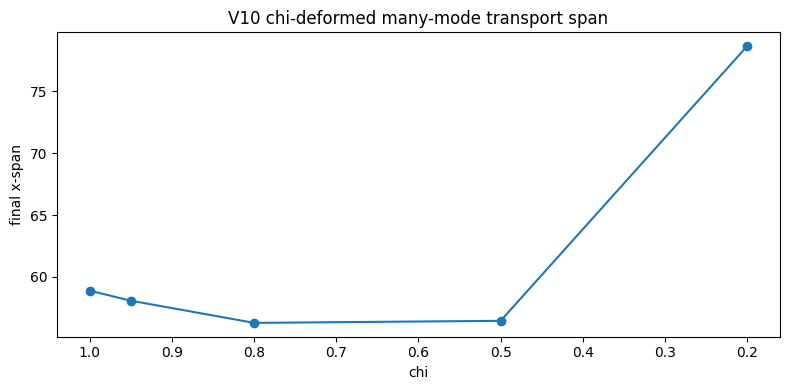

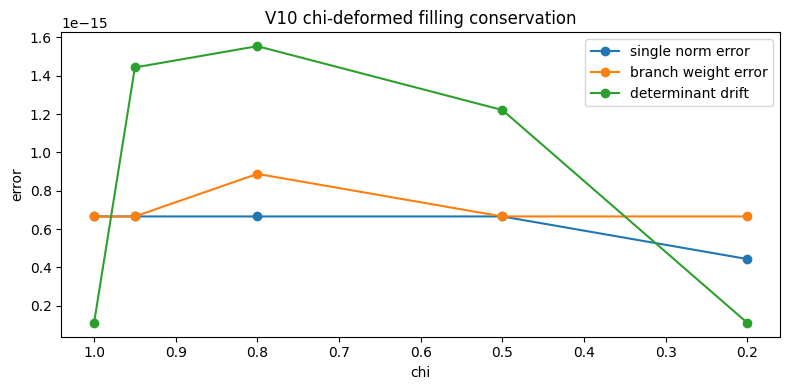

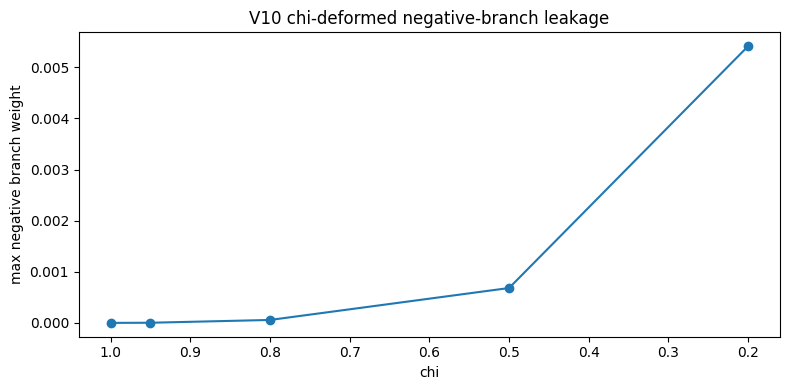

In [9]:
# ============================================================
# CELL 9 — CHI-DEFORMED MANY-MODE FILLING SCAN
# ============================================================

chi_values = [1.0, 0.95, 0.8, 0.5, 0.2]
t_final = 25.0
chi_rows = []

for chi in chi_values:
    print("Running chi =", chi)
    evolved = [evolve_exact(b["psi"], t_final, chi=chi) for b in basis]
    det_chi = slater_norm_sq_for_wavefunctions(evolved)
    GGt = np.zeros((M,M), dtype=complex)
    for i in range(M):
        for j in range(M):
            GGt[i,j] = inner_single(evolved[i], evolved[j])
    x_means = [expectation_x(w) for w in evolved]
    negs = [project_branch_weights(w, chi=chi)[1] for w in evolved]
    branch_errors = []
    for w in evolved:
        wp, wn = project_branch_weights(w, chi=chi)
        branch_errors.append(abs((wp+wn)-1.0))
    chi_rows.append({
        "chi": chi,
        "sqrt_chi": np.sqrt(chi),
        "t_final": t_final,
        "all_mode_det": det_chi,
        "det_error_vs_chi1_initial": abs(det_chi - initial_det),
        "max_single_norm_error": float(max(abs(norm_psi(w)-1.0) for w in evolved)),
        "max_branch_weight_error": float(max(branch_errors)),
        "max_negative_branch_weight": float(max(negs)),
        "x_mean_mean": float(np.mean(x_means)),
        "x_span": float(max(x_means)-min(x_means)),
        "max_gram_abs_drift_vs_initial": float(np.max(np.abs(np.abs(GGt)-initial_G_abs)))
    })

chi_df = pd.DataFrame(chi_rows)
chi_df.to_csv(OUT/"chi_deformed_many_mode_filling_scan_v10.csv", index=False)
display(chi_df)

print("Max chi single norm error:", chi_df["max_single_norm_error"].max())
print("Max chi branch weight error:", chi_df["max_branch_weight_error"].max())
print("Max chi determinant error:", chi_df["det_error_vs_chi1_initial"].max())
print("Chi x-span range:", float(chi_df["x_span"].max() - chi_df["x_span"].min()))

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["x_span"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel("chi")
plt.ylabel("final x-span")
plt.title("V10 chi-deformed many-mode transport span")
savefig("fig_v10_chi_many_mode_transport_span.png")

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["max_single_norm_error"], marker="o", label="single norm error")
plt.plot(chi_df["chi"], chi_df["max_branch_weight_error"], marker="o", label="branch weight error")
plt.plot(chi_df["chi"], chi_df["det_error_vs_chi1_initial"], marker="o", label="determinant drift")
plt.gca().invert_xaxis()
plt.xlabel("chi")
plt.ylabel("error")
plt.title("V10 chi-deformed filling conservation")
plt.legend()
savefig("fig_v10_chi_filling_conservation.png")

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["max_negative_branch_weight"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel("chi")
plt.ylabel("max negative branch weight")
plt.title("V10 chi-deformed negative-branch leakage")
savefig("fig_v10_chi_negative_branch_leakage.png")

In [10]:
# ============================================================
# CELL 10 — FINAL V10 VERDICT TABLE
# ============================================================

q_error = abs(float(packet["q_eff"]) + 1.0)
N_plus_error = abs(float(packet["N_plus"]) - 0.0)
N_zero_error = abs(float(packet["N_zero"]) - 1.0)
N_minus_error = abs(float(packet["N_minus"]) - 3.0)

alpha_beta_max_error = float(alpha_df["error"].max())

max_diag_error = float(np.max(np.abs(np.diag(G)-1)))
max_offdiag = float(np.max(np.abs(G - np.eye(M))))

duplicate_det = duplicate_collapse_test(0)
same_shell_det = slater_norm_sq([0,1])
separated_det = slater_norm_sq([0,2])
all_mode_det = all_det
overflow_duplicate_det = overflow_det

max_unitary_single_norm_error = float(prop_df["max_single_norm_error"].max())
max_unitary_det_error = float(prop_df["det_error_vs_initial"].max())
max_unitary_gram_drift = float(prop_df["max_gram_abs_drift"].max())

max_chi_single_norm_error = float(chi_df["max_single_norm_error"].max())
max_chi_branch_error = float(chi_df["max_branch_weight_error"].max())
max_chi_det_error = float(chi_df["det_error_vs_chi1_initial"].max())
max_chi_negative = float(chi_df["max_negative_branch_weight"].max())
chi_transport_span_range = float(chi_df["x_span"].max() - chi_df["x_span"].min())

capacity = int(M)
shell_capacity_ok = bool((shell_df["capacity"] == 2).all())

verdict_rows = [
    ("packet remains q=-1 scaffold", q_error, q_error < 1e-2),
    ("packet N_plus near 0", N_plus_error, N_plus_error < 5e-3),
    ("packet N_zero near 1", N_zero_error, N_zero_error < 5e-3),
    ("packet N_minus near 3", N_minus_error, N_minus_error < 5e-3),
    ("alpha/beta closure inherited", alpha_beta_max_error, alpha_beta_max_error < 1e-12),
    ("basis modes individually normalized", max_diag_error, max_diag_error < 1e-12),
    ("basis has finite nonzero capacity", capacity, capacity >= 4),
    ("duplicate occupancy collapses determinant", abs(duplicate_det), abs(duplicate_det) < 1e-12),
    ("same shell orthogonal internal filling allowed", same_shell_det, same_shell_det > 0.99),
    ("separated same-internal filling allowed", separated_det, separated_det > 0.99),
    ("all finite modes can be filled once", all_mode_det, all_mode_det > 0.95),
    ("overflow by duplicate occupancy forbidden", abs(overflow_duplicate_det), abs(overflow_duplicate_det) < 1e-10),
    ("two internal states per shell capacity", float(shell_capacity_ok), shell_capacity_ok),
    ("filling scan opens allowed determinants", float(fill_df["max_slater_norm_sq"].max()), fill_df["max_slater_norm_sq"].max() > 0.99),
    ("unitary single-mode norms preserved", max_unitary_single_norm_error, max_unitary_single_norm_error < 1e-12),
    ("unitary filled determinant preserved", max_unitary_det_error, max_unitary_det_error < 1e-10),
    ("unitary Gram overlaps preserved", max_unitary_gram_drift, max_unitary_gram_drift < 1e-10),
    ("chi-deformed single norms preserved", max_chi_single_norm_error, max_chi_single_norm_error < 1e-12),
    ("chi-deformed branch weights conserved", max_chi_branch_error, max_chi_branch_error < 1e-10),
    ("chi-deformed filled determinant preserved", max_chi_det_error, max_chi_det_error < 1e-8),
    ("chi-deformed negative leakage controlled", max_chi_negative, max_chi_negative < 2e-2),
    ("chi changes many-mode transport span", chi_transport_span_range, chi_transport_span_range > 1.0),
]

verdict = pd.DataFrame(verdict_rows, columns=["criterion", "value", "pass"])
verdict.to_csv(OUT/"final_many_mode_filling_v10_verdict.csv", index=False)

n_pass = int(verdict["pass"].sum())
n_criteria = int(len(verdict))
final_label = "PASS: many-mode fermion-like filling and shell-capacity bridge for ECSM electron-like packets" if n_pass == n_criteria else "CONDITIONAL/FAIL: many-mode filling criteria not all satisfied"

summary = {
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": packet["q_eff"],
    "m_lock_dimensionless": m_lock,
    "n_basis_modes": M,
    "shell_capacity_per_centre": 2,
    "duplicate_det": duplicate_det,
    "same_shell_det": same_shell_det,
    "separated_det": separated_det,
    "all_mode_det": all_mode_det,
    "overflow_duplicate_det": overflow_duplicate_det,
    "max_unitary_single_norm_error": max_unitary_single_norm_error,
    "max_unitary_det_error": max_unitary_det_error,
    "max_unitary_gram_drift": max_unitary_gram_drift,
    "max_chi_single_norm_error": max_chi_single_norm_error,
    "max_chi_branch_error": max_chi_branch_error,
    "max_chi_det_error": max_chi_det_error,
    "max_chi_negative_branch_weight": max_chi_negative,
    "chi_transport_span_range": chi_transport_span_range,
}

with open(OUT/"run_summary_v10.json", "w") as f:
    json.dump(summary, f, indent=2)

print(verdict.to_string(index=False))
print("\nFinal label:", final_label)
print(json.dumps(summary, indent=2))

manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir() if p.is_file()])})
manifest.to_csv(OUT/"output_file_manifest_v10.csv", index=False)
print("\nOutput files:")
display(manifest)

                                     criterion        value  pass
                  packet remains q=-1 scaffold 6.964280e-04  True
                          packet N_plus near 0 9.716379e-04  True
                          packet N_zero near 1 1.460081e-04  True
                         packet N_minus near 3 1.117646e-03  True
                  alpha/beta closure inherited 0.000000e+00  True
           basis modes individually normalized 4.440908e-16  True
             basis has finite nonzero capacity 8.000000e+00  True
     duplicate occupancy collapses determinant 0.000000e+00  True
same shell orthogonal internal filling allowed 1.000000e+00  True
       separated same-internal filling allowed 9.998973e-01  True
           all finite modes can be filled once 9.993839e-01  True
     overflow by duplicate occupancy forbidden 0.000000e+00  True
        two internal states per shell capacity 1.000000e+00  True
       filling scan opens allowed determinants 1.000000e+00  True
          

,file
0,alpha_beta_algebra_tests_v10.csv
1,capacity_overflow_duplicate_test_v10.csv
2,chi_deformed_many_mode_filling_scan_v10.csv
3,fig_v10_chi_filling_conservation.png
4,fig_v10_chi_many_mode_transport_span.png
5,fig_v10_chi_negative_branch_leakage.png
6,fig_v10_filling_capacity_scan.png
7,fig_v10_gram_overlap_matrix.png
8,fig_v10_many_mode_basis_densities.png
9,fig_v10_reference_packet_density.png


## Interpretation guide

A clean V10 pass means:

- duplicate occupancy collapses the many-packet determinant;
- each allowed basis mode can be filled once;
- finite capacity is explicit;
- two internal positive-subspace states per spatial centre behave as a simple shell-capacity proxy;
- adding a duplicate after filling all available modes is forbidden;
- common unitary propagation preserves the filling structure;
- chi-deformed propagation changes transport while preserving determinant/norm/branch accounting.

This is still **not full Fermi--Dirac thermodynamics** and not a full QFT derivation. It is the next bridge: two-packet exclusion -> many-mode finite filling.